# Изучение производства электроэнергии в Румынии

## О поисках датасета

Я искал данные на платформе kaggle, так как уже с ней знаком и имею на ней личный подтвержденный аккаунт (artemiambushev).
Выбрал область, которая связана с добычей/использованием/изучением угля. Итоговый датасет я нашел одним из первых, он привлек меня по следующим причинам:
- датасет имеет большое количество данных – заявлено 62810 значений для каждой колонки,
- все данные в одном csv файле,
- данные от реального оператора электроэнергии в Румынии,
- датасет обновляется каждый год.

Есть более интересный датасет – [open-database-on-global-coal-and-metal-mining](https://www.kaggle.com/datasets/simonjasansky/open-database-on-global-coal-and-metal-mining). Однако для работы с ним придется немного объединить данные из нескольких файлов. Более того, он не обновляется с 2021 года, что печально. Перед исследованием стоит обновить данные, которые уже доступны в том же источнике – [Global Material Flows Database](https://www.resourcepanel.org/global-material-flows-database). Оставлю его для следующих заданий.

В датасете с электроэнергией, хочу посмотреть долю использования угля.

## Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
#import numpy as np

from plotly.subplots import make_subplots

from datetime import datetime

## Загрузка данных

In [2]:
# Перед запуском убедитесь в установке python на компьютере
%pip install kaggle nbformat # Установка зависимостей для работы с Kaggle API и Jupyter Notebook
# переменная KAGGLE_API_TOKEN должна быть установлена в переменных окружения для доступа к Kaggle API

!kaggle datasets download --unzip --force stefancomanita/hourly-electricity-consumption-and-production # скачиваем датасет через kaggle CLI


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dataset URL: https://www.kaggle.com/datasets/stefancomanita/hourly-electricity-consumption-and-production
License(s): CC0-1.0
100%|██████████████████████████████████████| 1.18M/1.18M [00:00<00:00, 2.12MB/s]



In [3]:
df = pd.read_csv('electricityConsumptionAndProductioction.csv')

df.info() # Основная информация о загруженном наборе данных

<class 'pandas.DataFrame'>
RangeIndex: 62810 entries, 0 to 62809
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DateTime       62810 non-null  str  
 1   Consumption    62810 non-null  int64
 2   Production     62810 non-null  int64
 3   Nuclear        62810 non-null  int64
 4   Wind           62810 non-null  int64
 5   Hydroelectric  62810 non-null  int64
 6   Oil and Gas    62810 non-null  int64
 7   Coal           62810 non-null  int64
 8   Solar          62810 non-null  int64
 9   Biomass        62810 non-null  int64
dtypes: int64(9), str(1)
memory usage: 4.8 MB


- Датасет содержит 10 столбцов с дискретными данными;
- Есть 9 столбцов с числовыми данными (int64) и один со строковыми (str);
- При этом, ни в одном из столбцов нет пропущенных значений.

In [4]:
df # Посмотрим "все" данные в датафрейме

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30
...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14 19:00:00,7132,6937,1339,699,2560,1590,598,0,59
62806,2026-03-14 20:00:00,7027,6827,1339,744,2538,1571,579,0,58
62807,2026-03-14 21:00:00,6615,6612,1341,778,2291,1569,578,0,60
62808,2026-03-14 22:00:00,6063,6421,1335,701,2146,1556,586,0,61


## Проверка датасета или мини EDA

In [5]:
df.isnull().sum() # Поиск пропущенных значений по всем столбцам и строкам

DateTime         0
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64

In [6]:
def from_wd_to_iso_format(datetimewd: str) -> str:
    """Перевод календарного формата wd в ISO 8601"""
    return datetimewd.replace(' ', 'T')

In [7]:
num_rows = df.count().max()

start_datetime_wd, latest_datetime_wd = df['DateTime'][0], df['DateTime'][num_rows - 1]
print(f'До:\n{start_datetime_wd} – {latest_datetime_wd} \n{type(start_datetime_wd)} – {type(latest_datetime_wd)}')

start_datetime_iso, latest_datetime_iso = from_wd_to_iso_format(start_datetime_wd), from_wd_to_iso_format(latest_datetime_wd)
print(f'После:\n{start_datetime_iso} – {latest_datetime_iso} \n{type(start_datetime_iso)} – {type(latest_datetime_iso)}\n')


start_datetime = datetime.fromisoformat(start_datetime_iso)
latest_datetime = datetime.fromisoformat(latest_datetime_iso)

delta_datetime = latest_datetime - start_datetime
print(f'Прошло {delta_datetime.days * 24} часов с начала сбора данных.')

unique_timestamps_count = df['DateTime'].nunique()
print(f'При этом уникальных значений меньше на {delta_datetime.days * 24} - {unique_timestamps_count} = {delta_datetime.days * 24 - unique_timestamps_count} раз.')
print('Неужели дубликаты?')

До:
2019-01-01 00:00:00 – 2026-03-14 23:00:00 
<class 'str'> – <class 'str'>
После:
2019-01-01T00:00:00 – 2026-03-14T23:00:00 
<class 'str'> – <class 'str'>

Прошло 63096 часов с начала сбора данных.
При этом уникальных значений меньше на 63096 - 62799 = 297 раз.
Неужели дубликаты?


In [8]:
df_duplicated = df.duplicated().reset_index(name='Duplicated').drop(columns='index') # Находим и убираем дубликаты
df_duplicated = df_duplicated[df_duplicated['Duplicated'] == True] # Выделяются только дубликаты

In [9]:
df.loc[df_duplicated.index] # 

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
7180,2019-10-27 03:00:00,5196,4459,1373,74,725,719,1515,0,50
15917,2020-10-25 03:00:00,5220,5412,1418,1188,1098,594,1048,0,65
24822,2021-10-31 03:00:00,5341,5258,1415,141,934,1314,1393,0,58
33559,2022-10-30 03:00:00,4503,5269,1384,544,1289,924,1073,0,52


In [10]:
df.iloc[7177:7183] # Ближайшие данные к одному из дубликатов

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
7177,2019-10-27 02:00:00,5288,4557,1374,83,768,746,1535,0,51
7178,2019-10-27 03:00:00,5186,4478,1373,77,750,696,1532,0,49
7179,2019-10-27 03:00:00,5196,4459,1373,74,725,719,1515,0,50
7180,2019-10-27 03:00:00,5196,4459,1373,74,725,719,1515,0,50
7181,2019-10-27 04:00:00,5207,4440,1374,71,700,743,1499,0,51
7182,2019-10-27 05:00:00,5336,4541,1373,52,784,746,1535,0,51


Проверка на дубликаты показала, что **есть 4 момента времени, когда зафискировано несколько результатов**. От них лучше избавится.

In [11]:
df = df[df.duplicated(keep='first') == False].reset_index(drop=True) # Оставляем только последний из дубликатов по времени
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62806 entries, 0 to 62805
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DateTime       62806 non-null  str  
 1   Consumption    62806 non-null  int64
 2   Production     62806 non-null  int64
 3   Nuclear        62806 non-null  int64
 4   Wind           62806 non-null  int64
 5   Hydroelectric  62806 non-null  int64
 6   Oil and Gas    62806 non-null  int64
 7   Coal           62806 non-null  int64
 8   Solar          62806 non-null  int64
 9   Biomass        62806 non-null  int64
dtypes: int64(9), str(1)
memory usage: 4.8 MB


/var/folders/m3/h7nw3y316zd61yv0n1_8bs7h0000gn/T/ipykernel_24600/2272142738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Production type', y='MW', data=melted, palette='Set3')


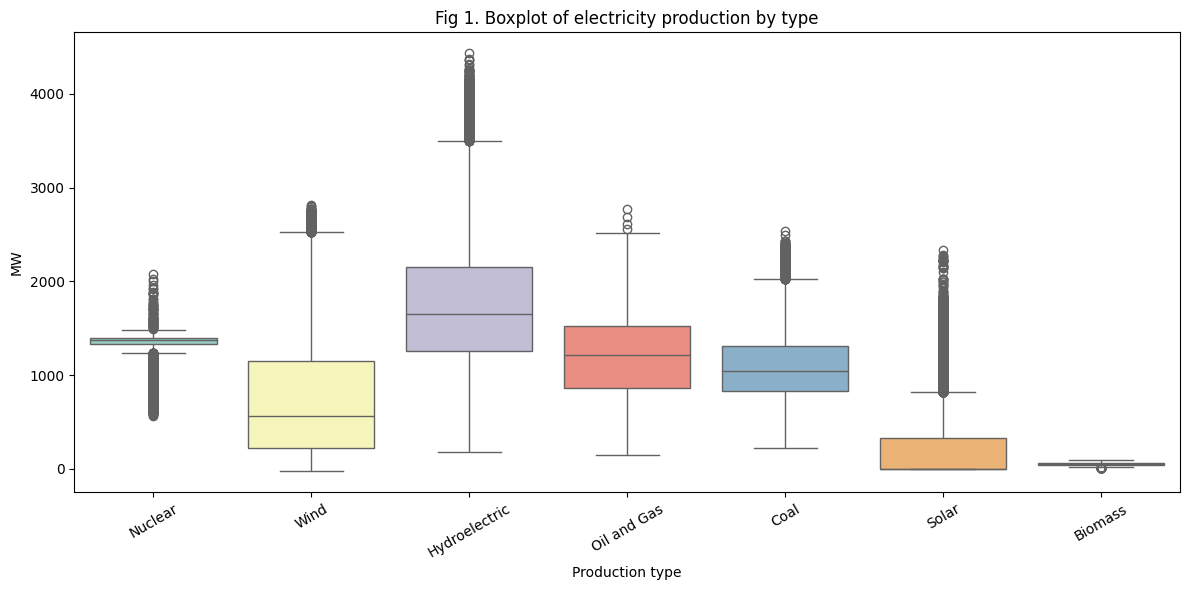

In [12]:
df_columns = df.columns.to_list()
production_types = df_columns[3:10] # Получаем список типов производства электроэнергии, исключая первые 3 столбца

production_columns = production_types

melted = df.melt(
    id_vars='DateTime',
    value_vars=production_columns,
    var_name='Production type',
    value_name='MW'
)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Production type', y='MW', data=melted, palette='Set3')
plt.title('Fig 1. Boxplot of electricity production by type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
# Подграфики для каждого типа производства
fig = make_subplots(rows=4, 
                    cols=2, 
                    subplot_titles=production_types, 
                    shared_xaxes=False, 
                    shared_yaxes=False)

row = 1
col = 1

for idx, production_type in enumerate(production_types):
    # Расчет частоты каждого значения MW для данного типа производства
    freq = df[production_type].value_counts().sort_index()
    
    # Add scatter plot
    fig.add_trace(
        go.Scatter(x=freq.index, 
                   y=freq.values, 
                   mode='markers', 
                   name=production_type),
        row=row, col=col
    )
    
    col += 1
    if col > 2:
        col = 1
        row += 1

fig.update_layout(height=800, 
                  width=1000, 
                  title_text="Fig 2. Scatter Plots of MW vs Frequency of Occurrence for Each Production Type"
                  )
fig.update_xaxes(title_text="MW")
fig.update_yaxes(title_text="Frequency")

fig.show()

### Эксперимент по удалению выбросов

In [14]:
# # Неудачный эксперимент по удалению выбросов, который убрал все летние показатели
# df = df[(df['Nuclear'] >= 1200) & (df['Nuclear'] <= 1500)]
# df = df[(df['Hydroelectric'] <= 3600)]
# df = df[(df['Coal'] <= 2050)]
# df = df[(df['Biomass'] >= 7)]
# df = df[(df['Wind'] <= 2500)]
# df = df[(df['Oil and Gas'] <= 2500)]
# df = df[(df['Solar'] <= 1000)] # Убрана часть выбросов

In [15]:
# # Подграфики для каждого типа производства
# fig = make_subplots(rows=4, 
#                     cols=2, 
#                     subplot_titles=production_types, 
#                     shared_xaxes=False, 
#                     shared_yaxes=False)

# row = 1
# col = 1

# for idx, production_type in enumerate(production_types):
#     # Расчет частоты каждого значения MW для данного типа производства
#     freq = df[production_type].value_counts().sort_index()
    
#     # Add scatter plot
#     fig.add_trace(
#         go.Scatter(x=freq.index, 
#                    y=freq.values, 
#                    mode='markers', 
#                    name=production_type),
#         row=row, col=col
#     )
    
#     col += 1
#     if col > 2:
#         col = 1
#         row += 1

# fig.update_layout(height=800, 
#                   width=1000, 
#                   title_text="Fig 2.1. Scatter Plots of MW vs Frequency of Occurrence for Each Production Type with Outliers Removed"
#                   )
# fig.update_xaxes(title_text="MW")
# fig.update_yaxes(title_text="Frequency")

# fig.show()

## Статистика по данным

In [16]:
df.describe()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
count,62806.000000,62806.000000,62806.000000,62806.000000,62806.000000,62806.000000,62806.000000,62806.000000,62806.000000
mean,6475.543117,6305.964987,1278.128284,761.573496,1756.565344,1169.530475,1087.081425,193.326386,54.577509
std,1062.435875,1041.557474,240.524857,660.509066,672.155387,441.783023,337.687698,302.889184,13.642586
min,2542.000000,2818.000000,562.000000,-26.000000,175.000000,146.000000,220.000000,0.000000,6.000000
25%,5652.000000,5561.000000,1332.000000,225.000000,1254.000000,859.000000,836.000000,0.000000,45.000000
50%,6411.000000,6254.000000,1370.000000,564.000000,1654.000000,1210.000000,1045.000000,4.000000,55.000000
75%,7230.000000,6999.750000,1396.000000,1146.000000,2153.000000,1527.000000,1311.000000,326.000000,65.000000
max,11986.000000,12179.000000,2081.000000,2811.000000,4434.000000,2770.000000,2537.000000,2331.000000,91.000000


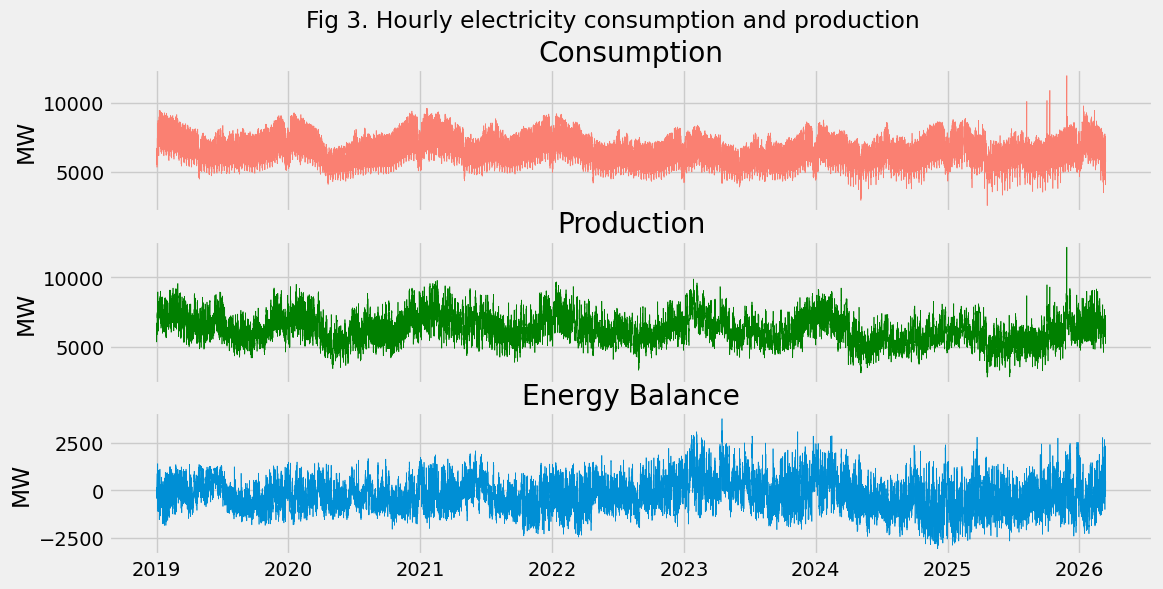

In [17]:
plt.style.use('fivethirtyeight')


# Преобразуем DateTime в datetime объекты для корректной оси X
df['DateTime'] = pd.to_datetime(df['DateTime'])
x = df.DateTime
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
colors = ['salmon', 'green', 'lightblue'] # Цвета для линий графиков

for i, column_name in enumerate(df_columns[1:3]): # первая колонка не зачтется, так как начали с 1
    ax = axes[i]
    y = df[column_name]
    ax.plot(x, y, label=column_name, linewidth=.5, color=colors[i])
    ax.set_ylabel('MW')
    ax.set_title(column_name)

ax = axes[2]
y = df['Production'] - df['Consumption'] # Баланс производства и потребления
ax.plot(x, y, label='Energy Balance', linewidth=.5)
ax.set_ylabel('MW')
ax.set_title('Energy Balance')
# Не работает как предполагалось.
# ax.fill_between(x, y, where=y > 0, facecolor='green', alpha=0.5, label='Surplus')
# ax.fill_between(x, y, where=y < 0, facecolor='red', alpha=0.5, label='Deficit')
# ax.legend()

fig.suptitle('Fig 3. Hourly electricity consumption and production')

plt.show()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

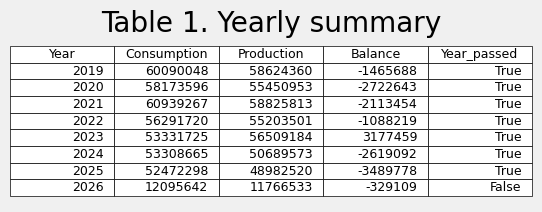

In [18]:
# Таблица с производством, потреблением и балансом за каждый год
df['Year'] = df['DateTime'].dt.year

yearly_summary = df.groupby('Year').agg({
    'Consumption': 'sum',
    'Production': 'sum'
}).reset_index()

yearly_summary['Balance'] = yearly_summary['Production'] - yearly_summary['Consumption']
yearly_summary['Year_passed'] = datetime.now().year > yearly_summary['Year'] # Прошел ли год, указанный в строке, по сравнению с текущим годом

# Выводим таблицу с помощью matplotlib
fig = plt.figure(figsize=(6, 2))
ax = fig.add_subplot(111)

ax.table(cellText=yearly_summary.values.tolist(), 
         colLabels=yearly_summary.columns.tolist(), 
         loc='center'
         )

ax.set_title('Table 1. Yearly summary') # Заголовок для таблицы

ax.axis('off')

In [19]:
general_max_power_generation = 0

for production_type in production_types:
    max_power_generation = df[production_type].max()
    general_max_power_generation += max_power_generation

print(f'Максимальная возможная мощность генерации электроэнергии в Румынии за период наблюдения: {general_max_power_generation} МВт')

Максимальная возможная мощность генерации электроэнергии в Румынии за период наблюдения: 17055 МВт


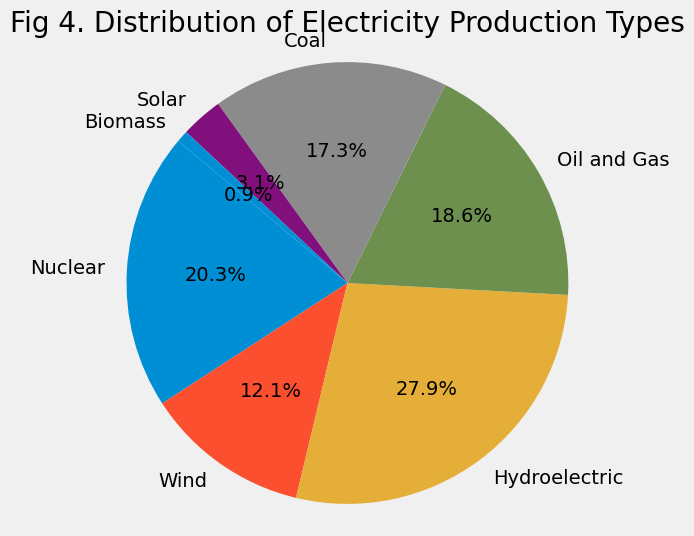

In [20]:
# Calculate total production for each type
production_totals = df[production_types].sum()

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(production_totals, labels=production_types, autopct='%1.1f%%', startangle=140)
plt.title('Fig 4. Distribution of Electricity Production Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

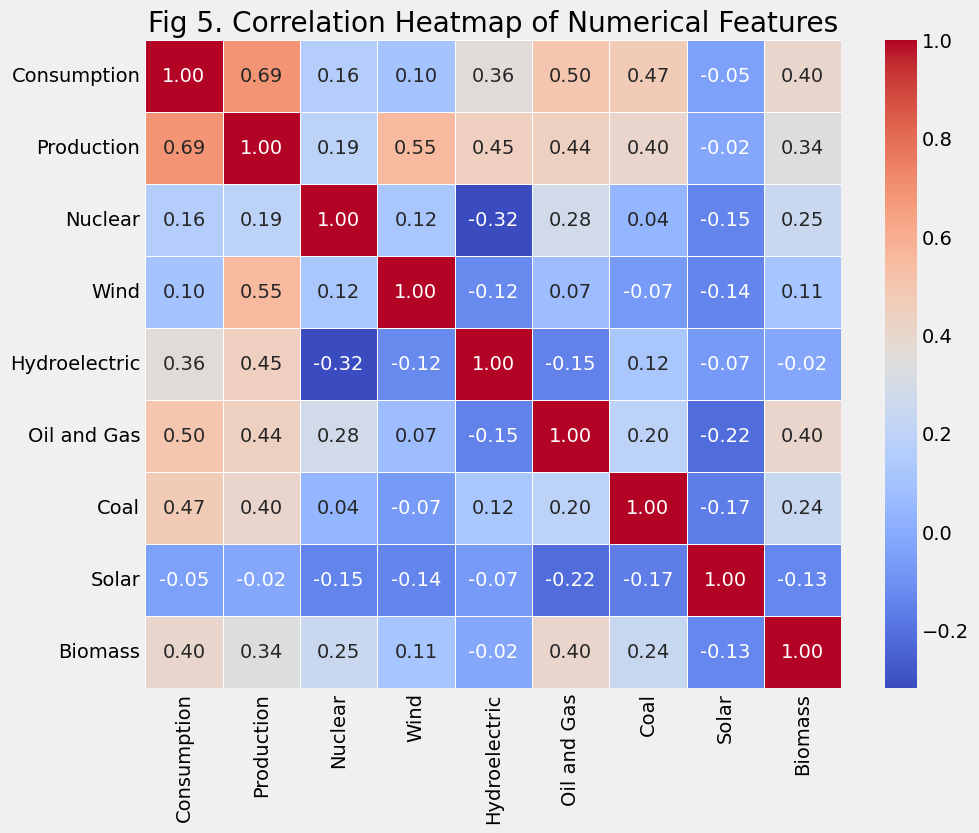

In [21]:
# Все числовые столбцы
numerical_columns = df_columns[1:]

# Корреляционная матрица
corr_matrix = df[numerical_columns].corr()

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Fig 5. Correlation Heatmap of Numerical Features')
plt.show()

## Дополнительные графики

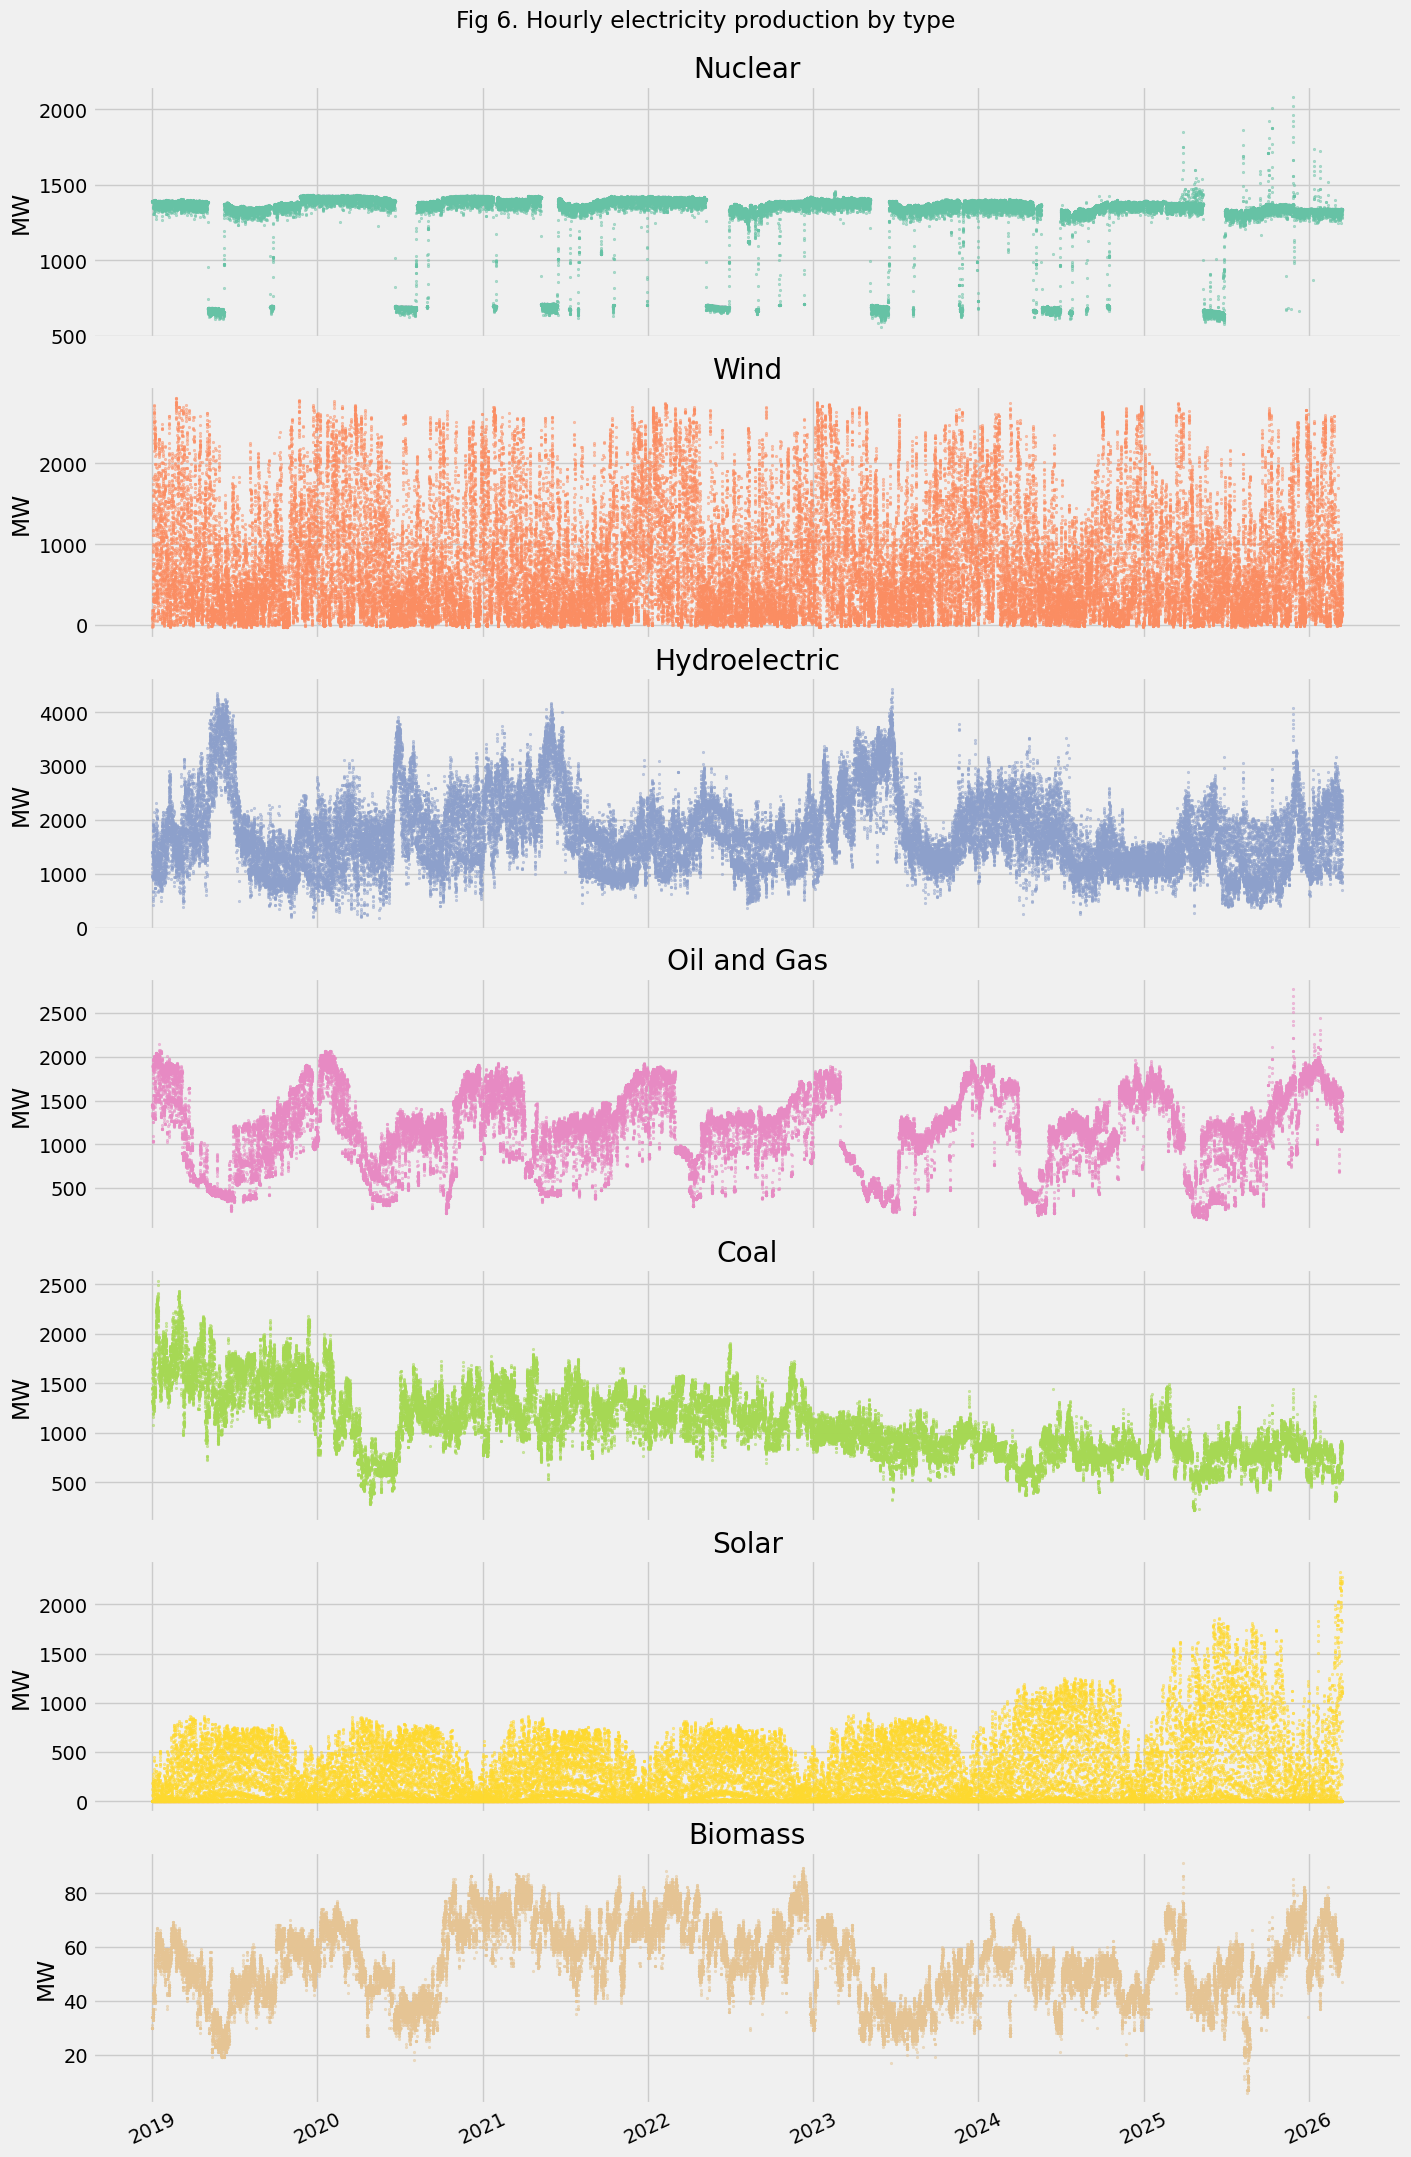

In [22]:
cols = 1
rows = (len(production_types) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3), constrained_layout=True, sharex=True)
axes = axes.flatten()

colors = sns.color_palette('Set2', n_colors=len(production_types))

for idx, production_type in enumerate(production_types):
    ax = axes[idx]
    ax.scatter(x, df[production_type], s=3, alpha=0.5, color=colors[idx])
    ax.set_title(production_type)
    ax.set_ylabel('MW')
    ax.tick_params(axis='x', rotation=25)

for ax in axes[len(production_types):]:
    ax.axis('off')

fig.suptitle('Fig 6. Hourly electricity production by type', y=1.02)
plt.show()

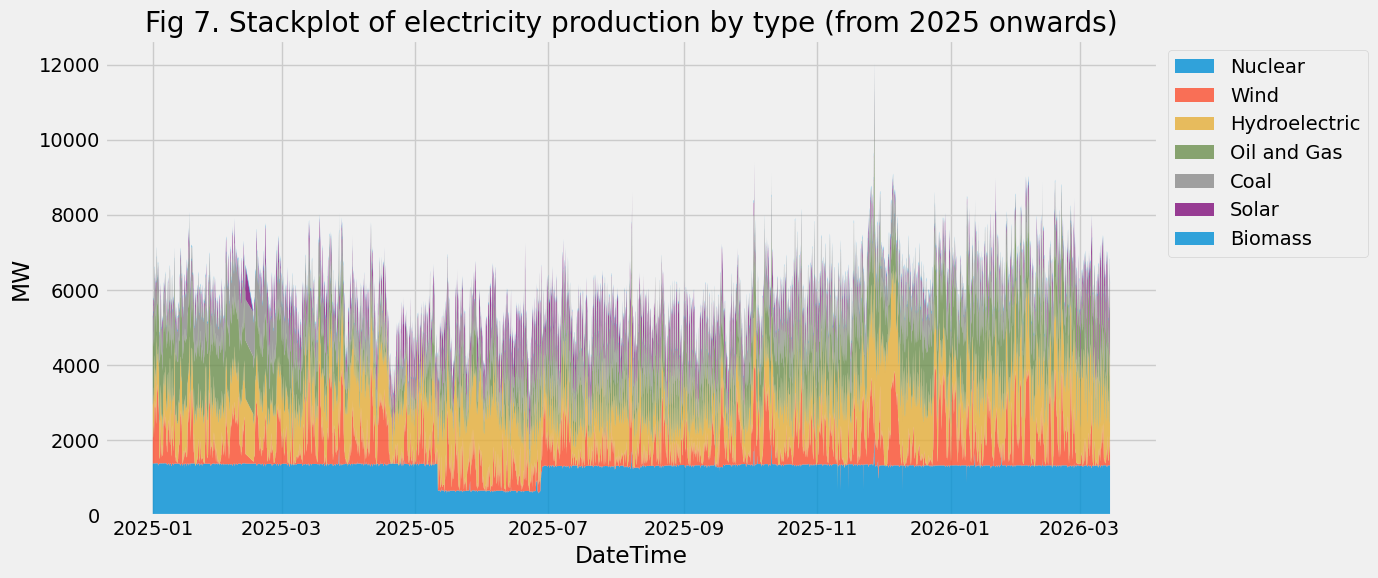

In [23]:
filtered_df = df[df['DateTime'] >= '2025-01-01']

x_range = filtered_df['DateTime']
y_stack = [filtered_df[col] for col in production_columns]

plt.figure(figsize=(14, 6))
plt.stackplot(x_range, *y_stack, labels=production_columns, alpha=0.8)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Fig 7. Stackplot of electricity production by type (from 2025 onwards)')
plt.xlabel('DateTime')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

# Выводы и обсуждения

Перед описанием результатов работы, информирую, что датасет имеет **ограничения**:
- период наблюдения: "1 Января 2019 г. - 22 Марта 2026 г.", 
- страна наблюдения: Румыния,
- интервал наблюдения: 1 час.

Построение графиков и проведение некоторых вычислений позволило вынести **выводы**.

Начиная обзор работ сообщим, что по графику №3 визуально видно, что потребление энергии зимой в среднем выше, чем в остальные сезоны. И наоборот, летом в целом меньше электропотребления [Fig. 3].

Во-вторых, наибольшая сумма показателя энергетического баланса в Румынии была в 2023 году. Страна обеспечивала себя и другие страны электроэнергией. Неизвестно, какие страны принимали электроэнергию из Румынии. При этом в 2025 год был самый высокий импорт электроэнергии в страну, что говорит о энергетеской зависимости [Table 1].

В третьих, было расчитано, что страна способна генерировать 17055 МВт энергии. Расчет теоретический и опирается исключительно на максимальные показатели энергогенерации по каждому из типов инфраструктуры.

Румыния пользуется широким спектром источников энергии (7 видов), начиная с **традиционных** угольных и нефтенных ресурсов, заканчивая **экологически нейтральными**: ветер и солнечное излучение. При этом **преобладает энергия с гидроэлектростанций** [Fig. 2]. Неизвестно использует ли Румыния продукты приливных и термо-электростанций. Последнее предположение стоит подтвердить дополнительно, чтобы избежать неточностей.

Наблюдается **средне-высокая связь** между показателями общего производства и общего потребления электричества. Отметим **среднюю связь** между общим потреблением и созданием электричества нефтехимическим производством. Определение силы связи получено с помощью шкалы Чеддока и корреляционной матрицы [Fig. 3].

В рамках приведения данных под нормальное распределение, проведена попытка удаления выбросов из датасета [Fig. 1]. После этого были удалены значения из каждого летнего периода. В итоге были рассмотрены данные с выбросами, чтобы сильно не изменять набор.

Наконец можно предложить приблизить данные к нормальному распределению. Например провести: 
1. стандартизацию, 
2. деление данных на сезоны 
3. и устранение выбросов в рамках сезонов.

После указаных действий повторить изучение данных корреляционным или иным анализом.